In [ ]:
import numpy as np
import torch
import torch.optim as optim

from D_quantile_regression import *
from E_actor_critic_networks import *
from C_trading_environment import *

action shape: torch.Size([8, 1])
action min/max: 0.4956408143043518 0.511164665222168
quantiles shape: torch.Size([8, 100])


<string>:20: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [7]:
class ReplayBuffer:
    def __init__(self, capacity, state_dim, action_dim):
        self.capacity = int(capacity)
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)

        self.s = np.zeros((self.capacity, self.state_dim), dtype=np.float32)
        self.a = np.zeros((self.capacity, self.action_dim), dtype=np.float32)
        self.r = np.zeros((self.capacity, 1), dtype=np.float32)
        self.s_next = np.zeros((self.capacity, self.state_dim), dtype=np.float32)
        self.done = np.zeros((self.capacity, 1), dtype=np.float32)

        self.idx = 0
        self.full = False

    def add(self, s, a, r, s_next, done):
        i = self.idx
        self.s[i] = np.asarray(s, dtype=np.float32)
        self.a[i] = np.asarray(a, dtype=np.float32)
        self.r[i] = float(r)
        self.s_next[i] = np.asarray(s_next, dtype=np.float32)
        self.done[i] = float(done)

        self.idx = (self.idx + 1) % self.capacity
        if self.idx == 0:
            self.full = True

    def sample(self, batch_size, device=None):
        n = len(self)
        b = min(int(batch_size), n)
        ids = np.random.randint(0, n, size=b)

        s = torch.from_numpy(self.s[ids]).to(device)
        a = torch.from_numpy(self.a[ids]).to(device)
        r = torch.from_numpy(self.r[ids]).to(device)
        s_next = torch.from_numpy(self.s_next[ids]).to(device)
        done = torch.from_numpy(self.done[ids]).to(device)

        return s, a, r, s_next, done

    def __len__(self):
        return self.capacity if self.full else self.idx

In [9]:
@torch.no_grad()
def soft_update(target, online, tau):
    """
    target <- (1-tau)*target + tau*online
    """
    for p_t, p in zip(target.parameters(), online.parameters()):
        p_t.data.mul_(1.0 - tau)
        p_t.data.add_(tau * p.data)

In [10]:
@torch.no_grad()
def compute_target_quantiles(critic_target, actor_target, s_next, r, done, gamma):
    """
    Outputs:
        Y: (B,M)
    """
    a_next = actor_forward(actor_target, s_next)              # (B,1)
    z_next = critic_forward(critic_target, s_next, a_next)    # (B,M)

    # broadcast: r/done are (B,1)
    Y = r + gamma * (1.0 - done) * z_next
    return Y

In [11]:
def update_critic(critic, optim_c, s, a, Y, taus, k):
    """
    Minimise quantile_huber_loss(Y, Z(s,a))
    """
    critic.train()
    optim_c.zero_grad()

    Z = critic_forward(critic, s, a)              # (B,M)
    loss = quantile_huber_loss(y=Y, z=Z, taus=taus, k=k)

    loss.backward()
    optim_c.step()

    return float(loss.detach().cpu().item())

In [12]:
def update_actor(actor, optim_a, critic, s, objective, alpha=0.95, lambda_std=1.645):
    actor.train()
    critic.eval()  # pas obligatoire, mais souvent stable

    optim_a.zero_grad()

    a = actor_forward(actor, s)                       # (B,1)
    Z = critic_forward(critic, s, a)                  # (B,M)

    obj = objective_from_quantiles(Z, objective=objective, alpha=alpha, lambda_std=lambda_std)
    loss = obj.mean()  # minimise le risque (loss)

    loss.backward()
    optim_a.step()

    return float(loss.detach().cpu().item())

In [13]:
def update_actor_maximize(actor, optim_a, critic, s, objective, alpha=0.95, lambda_std=1.645):
    actor.train()
    critic.eval()

    optim_a.zero_grad()
    a = actor_forward(actor, s)
    Z = critic_forward(critic, s, a)

    obj = objective_from_quantiles(Z, objective=objective, alpha=alpha, lambda_std=lambda_std)
    loss = -obj.mean()  # maximise l'objectif

    loss.backward()
    optim_a.step()
    return float(loss.detach().cpu().item())

In [14]:
def rollout_one_episode(env, actor, noise_std=0.1, device=None):
    """
    Outputs:
        episode_return: float
        transitions: list of (s,a,r,s_next,done)
    """
    actor.eval()

    state_np, env = env_reset(env)  # (5,)
    done = False

    episode_return = 0.0
    transitions = []

    while not done:
        s_t = torch.tensor(state_np, dtype=torch.float32, device=device).unsqueeze(0)  # (1,5)

        with torch.no_grad():
            a = actor_forward(actor, s_t).cpu().numpy()[0, 0]  # scalar

        # exploration
        a = float(a + np.random.normal(0.0, noise_std))
        a = max(0.0, min(1.0, a))

        next_state_np, r, done, info = env_step(env, a)

        transitions.append((state_np, np.array([a], dtype=np.float32), float(r), next_state_np, float(done)))
        episode_return += float(r)

        state_np = next_state_np

    return episode_return, transitions

In [15]:
def train(
    env,
    actor, critic,
    actor_t, critic_t,
    buffer,
    n_episodes=200,
    batch_size=256,
    updates_per_step=1,
    gamma=0.99,
    tau_soft=0.005,
    objective="mean_std",
    alpha=0.95,
    lambda_std=1.645,
    k_huber=1.0,
    M=100,
    lr_actor=1e-4,
    lr_critic=1e-4,
    noise_std=0.1,
    warmup_steps=1000,
    device=None,
    maximize_objective=True
):
    """
    Outputs:
        history: dict
    """
    actor.to(device); critic.to(device)
    actor_t.to(device); critic_t.to(device)

    # init target = online
    actor_t.load_state_dict(actor.state_dict())
    critic_t.load_state_dict(critic.state_dict())

    optim_a = optim.Adam(actor.parameters(), lr=lr_actor)
    optim_c = optim.Adam(critic.parameters(), lr=lr_critic)

    taus = make_quantile_grid(M, device=device)  # (M,)

    history = {
        "returns": [],
        "actor_loss": [],
        "critic_loss": [],
        "buffer_len": [],
    }

    total_steps = 0

    for ep in range(int(n_episodes)):
        ep_return, transitions = rollout_one_episode(env, actor, noise_std=noise_std, device=device)
        history["returns"].append(ep_return)

        # add transitions
        for (s, a, r, s_next, done) in transitions:
            buffer.add(s, a, r, s_next, done)
            total_steps += 1

            # updates
            if len(buffer) >= max(batch_size, warmup_steps):
                for _ in range(int(updates_per_step)):
                    s_b, a_b, r_b, s_next_b, done_b = buffer.sample(batch_size, device=device)

                    # targets
                    Y = compute_target_quantiles(critic_t, actor_t, s_next_b, r_b, done_b, gamma)

                    # critic
                    c_loss = update_critic(critic, optim_c, s_b, a_b, Y, taus, k_huber)

                    # actor
                    if maximize_objective:
                        a_loss = update_actor_maximize(actor, optim_a, critic, s_b, objective, alpha, lambda_std)
                    else:
                        a_loss = update_actor(actor, optim_a, critic, s_b, objective, alpha, lambda_std)

                    # soft updates
                    soft_update(actor_t, actor, tau_soft)
                    soft_update(critic_t, critic, tau_soft)

                history["critic_loss"].append(c_loss)
                history["actor_loss"].append(a_loss)
            else:
                history["critic_loss"].append(np.nan)
                history["actor_loss"].append(np.nan)

        history["buffer_len"].append(len(buffer))

        if (ep + 1) % 10 == 0:
            print(f"[ep {ep+1}/{n_episodes}] return={ep_return:.4f} buffer={len(buffer)} "
                  f"c_loss={history['critic_loss'][-1]} a_loss={history['actor_loss'][-1]}")

    return history

In [16]:
RUN_TRAIN = False

if RUN_TRAIN:
    # ---- params env
    params = {
        "r": 0.01,
        "q": 0.0,
        "v": 0.5,
        "rho": -0.3,
        "lambda_day": 1.0,
        "kappa": 0.01,
        "T_days": 30,
        "dt": 1/252,
        "T_client_days": 60,
        "T_hedge_days": 30,
        "S0": 100.0,
        "sigma0": 0.2,
    }

    env = init_env(params, seed=123)

    # ---- nets
    state_dim = 5
    action_dim = 1
    M = 100

    actor = build_actor(state_dim=state_dim, hidden=256, n_layers=3).to(device)
    critic = build_critic_quantile(state_dim=state_dim, action_dim=action_dim, M=M).to(device)

    actor_t = build_actor(state_dim=state_dim, hidden=256, n_layers=3).to(device)
    critic_t = build_critic_quantile(state_dim=state_dim, action_dim=action_dim, M=M).to(device)

    # ---- buffer
    buffer = ReplayBuffer(capacity=200_000, state_dim=state_dim, action_dim=action_dim)

    history = train(
        env=env,
        actor=actor, critic=critic,
        actor_t=actor_t, critic_t=critic_t,
        buffer=buffer,
        n_episodes=50,
        batch_size=256,
        updates_per_step=1,
        gamma=0.99,
        tau_soft=0.005,
        objective="cvar",      # "mean_std" / "var" / "cvar"
        alpha=0.95,
        lambda_std=1.645,
        k_huber=1.0,
        M=M,
        lr_actor=1e-4,
        lr_critic=1e-4,
        noise_std=0.10,
        warmup_steps=1000,
        device=device,
        maximize_objective=True
    )

[ep 10/50] return=13.8983 buffer=300 c_loss=nan a_loss=nan
[ep 20/50] return=-6.6360 buffer=600 c_loss=nan a_loss=nan
[ep 30/50] return=-13.2418 buffer=900 c_loss=nan a_loss=nan
[ep 40/50] return=444158237.1936 buffer=1200 c_loss=525395.375 a_loss=-7423403.5
[ep 50/50] return=365652.4298 buffer=1500 c_loss=1339433.125 a_loss=-19366858.0


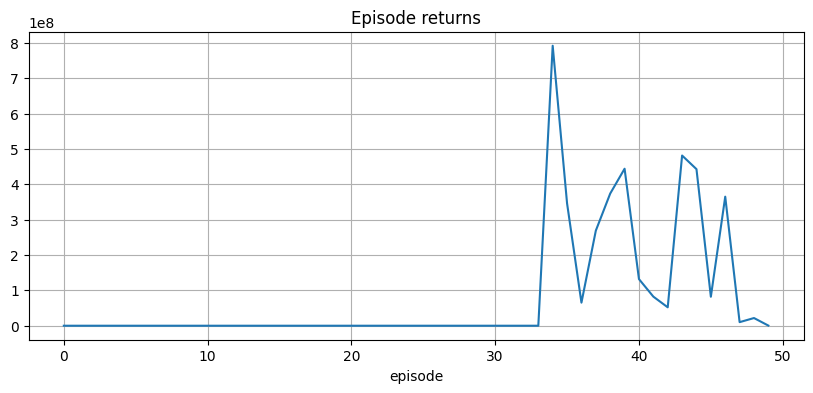

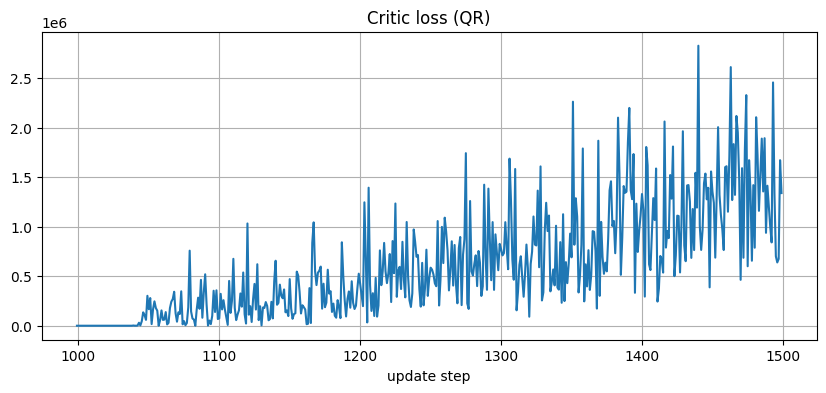

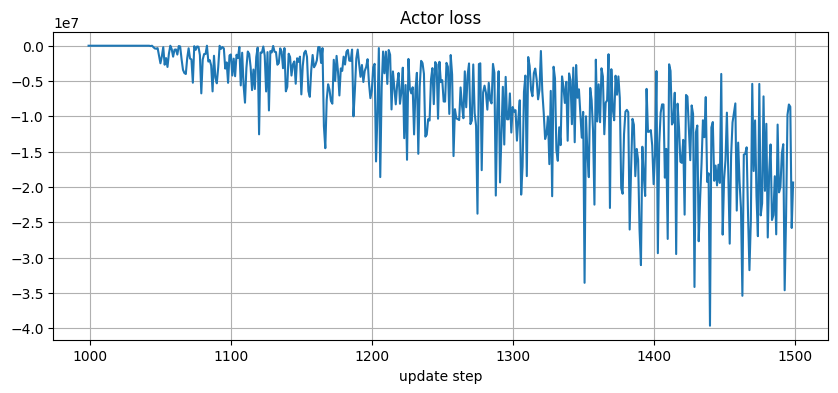

In [17]:
if "history" in globals():
    import matplotlib.pyplot as plt
    import numpy as np

    plt.figure(figsize=(10,4))
    plt.plot(history["returns"])
    plt.title("Episode returns")
    plt.xlabel("episode")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(history["critic_loss"])
    plt.title("Critic loss (QR)")
    plt.xlabel("update step")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(history["actor_loss"])
    plt.title("Actor loss")
    plt.xlabel("update step")
    plt.grid(True)
    plt.show()
